In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv('C:/Users/Harshit Srivastava/OneDrive/Desktop/Internship/earthquake_alert_balanced_dataset.csv')
data.head()

,magnitude,depth,cdi,mmi,sig,alert
0,7.0,14.0,8.0,7.0,0.0,green
1,6.9,25.0,4.0,4.0,-33.0,green
2,7.0,579.0,3.0,3.0,-13.0,green
3,7.3,37.0,5.0,5.0,65.0,green
4,6.6,624.0,0.0,2.0,-98.0,green


In [3]:
data.describe()

,magnitude,depth,cdi,mmi,sig
count,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000
mean,7.061008,50.321538,6.976154,6.939231,-9.749231
std,0.423738,104.348286,2.244875,1.354774,62.245214
min,6.500000,2.000000,0.000000,1.000000,-128.000000
25%,6.700000,12.000000,6.000000,6.000000,-54.000000
50%,7.000000,19.000000,8.000000,7.000000,-7.000000
75%,7.300000,38.000000,8.000000,8.000000,31.000000
max,8.600000,670.000000,9.000000,9.000000,127.000000


<Axes: xlabel='sig', ylabel='alert'>

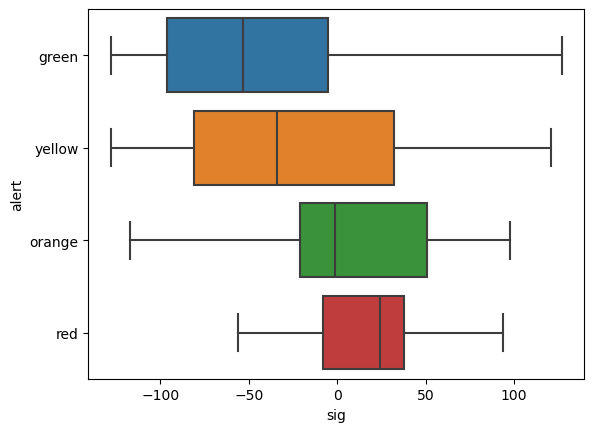

In [4]:
sns.boxplot(x=data['sig'],y=data['alert'])

<Axes: xlabel='depth', ylabel='alert'>

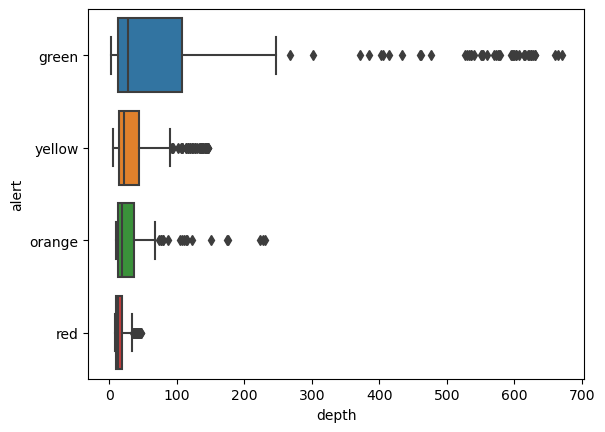

In [5]:
sns.boxplot(x=data['depth'],y=data['alert'])

In [6]:
data.shape

(1300, 6)

In [7]:
data = data.drop_duplicates()
data.shape

(1256, 6)

<Axes: xlabel='alert', ylabel='count'>

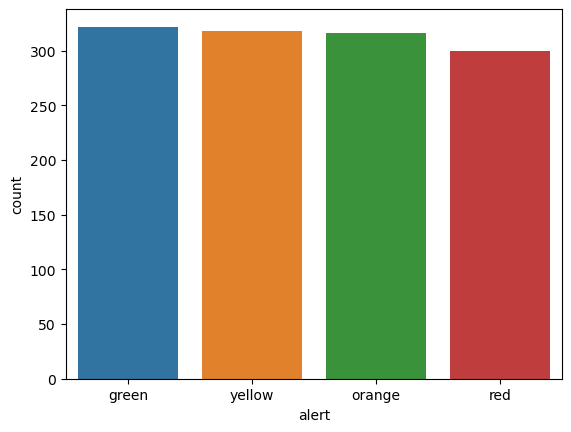

In [8]:
sns.countplot(x='alert',data=data)

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1256 entries, 0 to 1299
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   magnitude  1256 non-null   float64
 1   depth      1256 non-null   float64
 2   cdi        1256 non-null   float64
 3   mmi        1256 non-null   float64
 4   sig        1256 non-null   float64
 5   alert      1256 non-null   object 
dtypes: float64(5), object(1)
memory usage: 68.7+ KB


In [11]:
X=data.drop('alert',axis=1)
X

,magnitude,depth,cdi,mmi,sig
0,7.00,14.0,8.0,7.0,0.0
1,6.90,25.0,4.0,4.0,-33.0
2,7.00,579.0,3.0,3.0,-13.0
3,7.30,37.0,5.0,5.0,65.0
4,6.60,624.0,0.0,2.0,-98.0
...,...,...,...,...,...
1295,6.87,11.0,9.0,7.0,13.0
1296,7.85,93.0,8.0,6.0,-51.0
1297,7.48,142.0,7.0,6.0,120.0
1298,7.04,51.0,7.0,6.0,-115.0


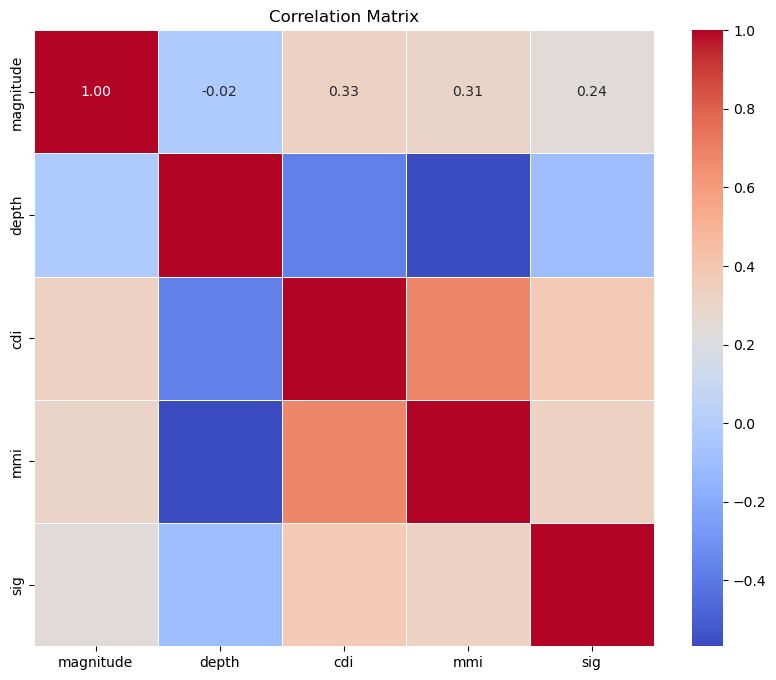

In [12]:
corr_matrix = X.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(data['alert'])
y_encoded

array([0, 0, 0, ..., 3, 3, 3])

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[-1.43689245e-01, -3.52519257e-01,  4.63322547e-01,
         6.01506748e-02,  1.66882250e-01],
       [-3.80035097e-01, -2.48606177e-01, -1.31901473e+00,
        -2.14031285e+00, -3.62421048e-01],
       [-1.43689245e-01,  4.98483439e+00, -1.76459904e+00,
        -2.87380069e+00, -4.16311704e-02],
       ...,
       [ 9.90770842e-01,  8.56651126e-01,  1.77382292e-02,
        -6.73337166e-01,  2.09162151e+00],
       [-4.91509048e-02, -2.99344280e-03,  1.77382292e-02,
        -6.73337166e-01, -1.67765955e+00],
       [-1.32541850e+00, -3.99752475e-01,  9.08906866e-01,
         7.93638515e-01, -2.98263072e-01]])